# Introduction :-

In Chapter 3, you saw how to fine-tune a model for text classification. In this chapter, we will tackle the following common language tasks that are essential for working with both traditional NLP models and modern LLMs:


* Token classification

* Masked language modeling (like BERT)

* Summarization

* Translation

* Causal language modeling pretraining (like GPT-2)

* Question answering

These fundamental tasks form the foundation of how Large Language Models (LLMs) work and understanding them is crucial for effectively working with today’s most advanced language models.

To do this, you’ll need to leverage everything you learned about the `Trainer API` and the 🤗 `Accelerate` library in Chapter 3, the 🤗 Datasets library in Chapter 5, and the 🤗 Tokenizers library in Chapter 6. so this is really the chapter where everything comes together!

Each section can be read independently and will show you how to train a model with the `Trainer` API or with your own training loop, using 🤗 Accelerate. The `Trainer` API is great for fine-tuning or training your model without worrying about what’s going on behind the scenes, while the training loop with `Accelerate` will let you customize any part you want more easily.

# Token classification :-

The first application we’ll explore is token classification. This generic task encompasses any problem that can be formulated as “attributing a label to each token in a sentence,” such as:

* **Named entity recognition (NER):** Find the entities (such as persons, locations, or organizations) in a sentence. This can be formulated as attributing a label to each token by having one class per entity and one class for “no entity.”

* **Part-of-speech tagging (POS):** Mark each word in a sentence as corresponding to a particular part of speech (such as noun, verb, adjective, etc.).

* **Chunking:** Find the tokens that belong to the same entity. This task (which can be combined with POS or NER) can be formulated as attributing one label (usually B-) to any tokens that are at the beginning of a chunk, another label (usually I-) to tokens that are inside a chunk, and a third label (usually O) to tokens that don’t belong to any chunk.

Of course, there are many other types of token classification problem; those are just a few representative examples. In this section, we will fine-tune a model (BERT) on a NER task, which will then be able to compute predictions like this one:

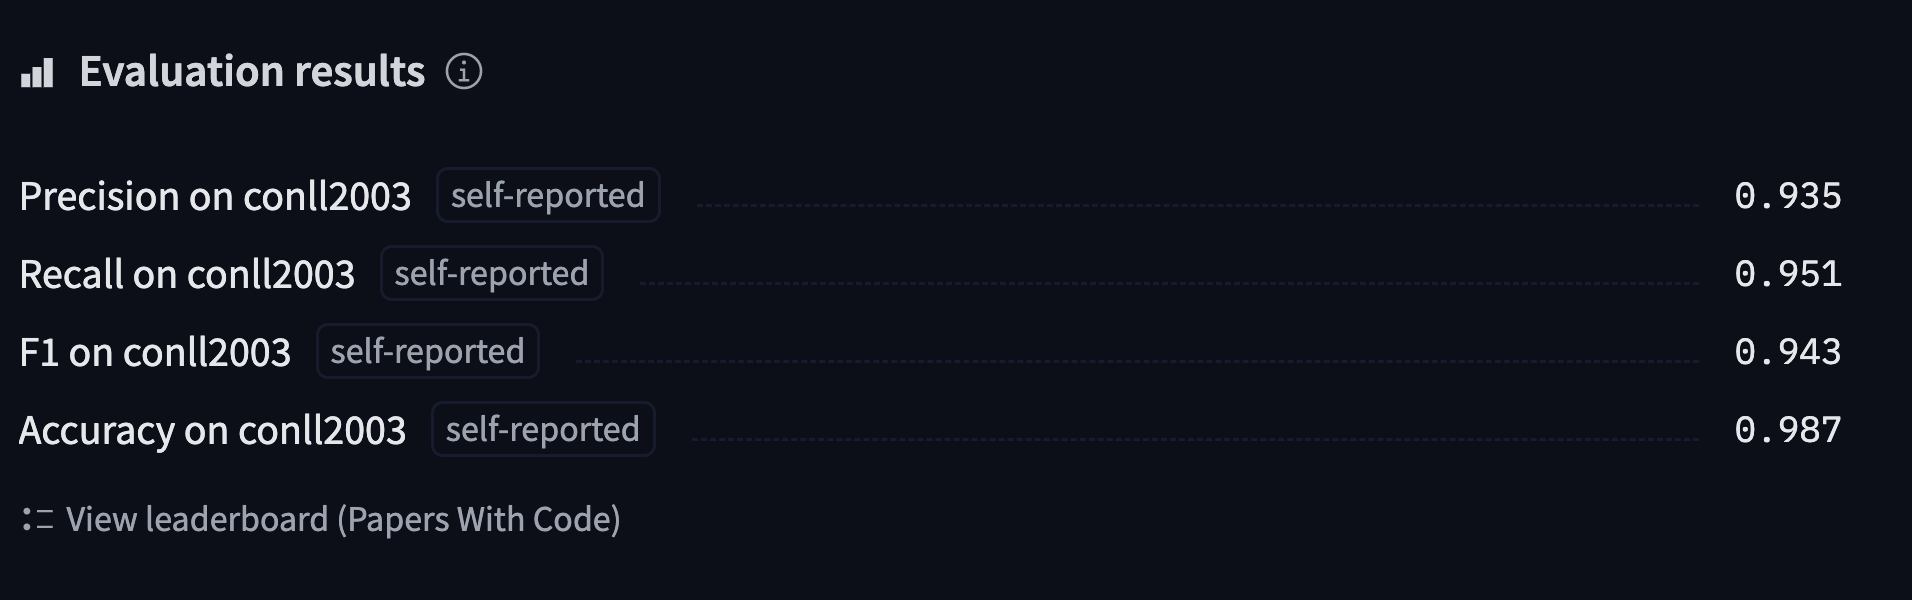

## Preparing the data :-

First things first, we need a dataset suitable for token classification. In this section we will use the **CoNLL-2003 dataset**, which contains news stories from Reuters.

> 💡 As long as your dataset consists of texts split into words with their corresponding labels, you will be able to adapt the data processing procedures described here to your own dataset. Refer back to Chapter 5 if you need a refresher on how to load your own custom data in a Dataset.

#### The CoNLL-2003 dataset

To load the CoNLL-2003 dataset, we use the `load_dataset()` method from the 🤗 Datasets library:

In [1]:
from datasets import load_dataset

raw_datasets = load_dataset("BramVanroy/conll2003")

This will download and cache the dataset, like we saw in Chapter 3 for the GLUE MRPC dataset. Inspecting this object shows us the columns present and the split between the training, validation, and test sets:

In [3]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})

In particular, we can see the dataset contains labels for the three tasks we mentioned earlier: NER, POS, and chunking. A big difference from other datasets is that the input texts are not presented as sentences or documents, but lists of words (that column is called tokens, but it contains words in the sense that these are pre-tokenized inputs that still need to go through the tokenizer for subword tokenization).

Let’s have a look at the first element of the training set:

In [4]:
raw_datasets["train"][0]["tokens"]

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']

Since we want to perform named entity recognition, we will look at the `NER` tags:

In [5]:
raw_datasets["train"][0]["ner_tags"]

[3, 0, 7, 0, 0, 0, 7, 0, 0]

Those are the labels as integers ready for training, but they’re not necessarily useful when we want to inspect the data. Like for text classification, we can access the correspondence between those integers and the label names by looking at the `features` attribute of our dataset:

In [2]:
ner_feature = raw_datasets["train"].features["ner_tags"]
ner_feature

List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']))

So this column contains elements that are sequences of `ClassLabels`. The type of the elements of the sequence is in the `feature` attribute of this `ner_feature`, and we can access the list of names by looking at the `names` attribute of that `feature`:

In [3]:
label_names = ner_feature.feature.names
label_names

['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

We already saw these labels when digging into the `token-classification` pipeline in Chapter 6, but for a quick refresher:

* `O` means the word doesn’t correspond to any entity.

* `B-PER/I-PER` means the word corresponds to the beginning of/is inside a person entity.

Now decoding the labels we saw earlier gives us this:

In [4]:
words = raw_datasets["train"][0]["tokens"]
labels = raw_datasets["train"][0]["ner_tags"]
line1 = ""
line2 = ""
for word, label in zip(words, labels):
    full_label = label_names[label]
    max_length = max(len(word), len(full_label))
    line1 += word + " " * (max_length - len(word) + 1)
    line2 += full_label + " " * (max_length - len(full_label) + 1)

print(line1)
print(line2)

EU    rejects German call to boycott British lamb . 
B-ORG O       B-MISC O    O  O       B-MISC  O    O 


## Processing the data 

As usual, our texts need to be converted to token IDs before the model can make sense of them. As we saw in Chapter 6, a big difference in the case of token classification tasks is that we have pre-tokenized inputs. Fortunately, the tokenizer API can deal with that pretty easily; we just need to warn the `tokenizer` with a special flag.

To begin, let’s create our `tokenizer` object. As we said before, we will be using a BERT pretrained model, so we’ll start by downloading and caching the associated tokenizer:

In [5]:
from transformers import AutoTokenizer

model_checkpoint = "bert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

You can replace the `model_checkpoint` with any other model you prefer from the Hub, or with a local folder in which you’ve saved a pretrained model and a tokenizer. The only constraint is that the tokenizer needs to be backed by the 🤗 Tokenizers library, so there’s a “fast” version available. And to check that the `tokenizer` object you’re using is indeed backed by 🤗 Tokenizers you can look at its `is_fast` attribute:

In [6]:
tokenizer.is_fast

True

To tokenize a pre-tokenized input, we can use our `tokenizer` as usual and just add `is_split_into_words=True`:

In [7]:
inputs = tokenizer(raw_datasets["train"][0]["tokens"], is_split_into_words=True)
print(inputs.tokens())

['[CLS]', 'EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'la', '##mb', '.', '[SEP]']


As we can see, the tokenizer added the special tokens used by the model (`[CLS]` at the beginning and `[SEP]` at the end) and left most of the words untouched. The word `lamb`, however, was tokenized into two subwords, `la` and `##mb`. This introduces a mismatch between our inputs and the labels: the list of labels has only 9 elements, whereas our input now has 12 tokens. Accounting for the special tokens is easy (we know they are at the beginning and the end), but we also need to make sure we align all the labels with the proper words.

Fortunately, because we’re using a fast tokenizer we have access to the 🤗 Tokenizers superpowers, which means we can easily map each token to its corresponding word (as seen in Chapter 6):

In [8]:
inputs.word_ids()

[None, 0, 1, 2, 3, 4, 5, 6, 7, 7, 8, None]

With a tiny bit of work, we can then expand our label list to match the tokens. The first rule we’ll apply is that special tokens get a label of `-100`. This is because by default `-100` is an index that is ignored in the loss function we will use (cross entropy). Then, each token gets the same label as the token that started the word it’s inside, since they are part of the same entity. For tokens inside a word but not at the beginning, we replace the `B-` with `I-` (since the token does not begin the entity):

In [9]:
def align_labels_with_tokens(labels, word_ids):
    new_labels = []
    current_word = None
    
    for word_id in word_ids:
        if word_id != current_word:
            # Start of a new word!
            current_word = word_id
            label = -100 if word_id is None else labels[word_id]
            new_labels.append(label)
        elif word_id is None:
            # Special token
            new_labels.append(-100)
        else:
            # Same word as previous token
            label = labels[word_id]
            # If the label is B-XXX we change it to I-XXX
            if label % 2 == 1:
                label += 1
            new_labels.append(label)

    return new_labels

The `label % 2 == 1` trick is just a mathematical way to detect `B-` labels (they're odd numbers in the label list) and convert them to `I-` (even numbers) by adding 1.

The original `ner_tags` has **one label per word**. But after **tokenization, one word can become multiple subword tokens**. So now you have more tokens than labels — they don't match anymore. So for handling this we gotta do some steps to align the labels properly with their tokens.

Let’s try it out on our first sentence:

In [10]:
labels = raw_datasets["train"][0]["ner_tags"]
word_ids = inputs.word_ids()
print(labels)
print(align_labels_with_tokens(labels, word_ids))

[3, 0, 7, 0, 0, 0, 7, 0, 0]
[-100, 3, 0, 7, 0, 0, 0, 7, 0, 0, 0, -100]


As we can see, our function added the `-100` for the two special tokens at the beginning and the end, and a new `0` for our word that was split into two tokens.

To preprocess our whole dataset, we need to tokenize all the inputs and apply `align_labels_with_tokens()` on all the labels. To take advantage of the speed of our fast tokenizer, it’s best to tokenize lots of texts at the same time, so we’ll write a function that processes a list of examples and use the `Dataset.map()` method with the option `batched=True`. The only thing that is different from our previous example is that the `word_ids()` function needs to get the index of the example we want the word IDs of when the inputs to the tokenizer are lists of texts (or in our case, list of lists of words), so we add that too:

In [11]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(
        examples["tokens"], truncation=True, is_split_into_words=True
    )
    all_labels = examples["ner_tags"]
    new_labels = []
    for i, labels in enumerate(all_labels):
        word_ids = tokenized_inputs.word_ids(i)
        new_labels.append(align_labels_with_tokens(labels, word_ids))

    tokenized_inputs["labels"] = new_labels
    return tokenized_inputs

Note that we haven’t padded our inputs yet; we’ll do that later, when creating the batches with a data collator.

We can now apply all that preprocessing in one go on the other splits of our dataset:

In [12]:
tokenized_datasets = raw_datasets.map(
    tokenize_and_align_labels,
    batched=True,   # Default is 1000 samples per batch
    remove_columns=raw_datasets["train"].column_names,    # Because after tokenizing and aligning labels, the original columns (tokens, ner_tags, pos_tags etc) are no longer needed
)

## Fine-tuning the model with the Trainer API 

The actual code using the `Trainer` will be the same as before; the only changes are the way the data is collated into a batch and the metric computation function.

#### Data collation 

We can’t just use a `DataCollatorWithPadding` like in Chapter 3 because that only pads the inputs (input IDs, attention mask, and token type IDs). Here our labels should be padded the exact same way as the inputs so that they stay the same size, using `-100` as a value so that the corresponding predictions are ignored in the loss computation.

**Wait! CLS and SEP tokens already have -100 for their labels and -100 as label for padding as well? Then how would model know and learn the starting/CLS and end/SEP of the sentence?!**

Two separate things happening here:

**`-100` affects loss calculation only** — not the forward pass. The model still SEES and PROCESSES `[CLS]` and `[SEP]` tokens during the forward pass through all the attention layers. They still attend to other tokens and influence the hidden states.

**Loss calculation** is only the final step where you compare predictions against true labels. `-100` just tells the loss function "don't penalize me for whatever I predicted at this position" — because there's no meaningful entity label for `[CLS]`/`[SEP]`.

So:
- **Forward pass** → model sees ALL tokens including `[CLS]`, `[SEP]`, padding → processes them normally
- **Loss calculation** → `-100` positions get skipped → model not penalized for those predictions

`[CLS]` and `[SEP]` still do their job of providing sentence structure context during attention. They're just excluded from the label prediction evaluation since we don't care what entity label the model assigns to them.


This is all done by a `DataCollatorForTokenClassification` - `DataCollatorForTokenClassification` specifically pads both the inputs AND the labels simultaneously with `-100` for label padding and `0` for inputs — since regular DataCollatorWithPadding only pads inputs.. Like the `DataCollatorWithPadding`, it takes the tokenizer used to preprocess the inputs:

In [13]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

To test this on a few samples, we can just call it on a list of examples from our tokenized training set:

In [14]:
batch = data_collator([tokenized_datasets["train"][i] for i in range(2)])
print(batch["input_ids"])
print(batch["labels"])

tensor([[  101,  7270, 22961,  1528,  1840,  1106, 21423,  1418,  2495, 12913,
           119,   102],
        [  101,  1943, 14428,   102,     0,     0,     0,     0,     0,     0,
             0,     0]])
tensor([[-100,    3,    0,    7,    0,    0,    0,    7,    0,    0,    0, -100],
        [-100,    1,    2, -100, -100, -100, -100, -100, -100, -100, -100, -100]])


Let’s compare this to the labels for the first and second elements in our dataset:

In [15]:
for i in range(2):
    print(tokenized_datasets["train"][i]["labels"])

[-100, 3, 0, 7, 0, 0, 0, 7, 0, 0, 0, -100]
[-100, 1, 2, -100]


**DataCollator and mapping are separate steps — here's why:**

`.map()` with `tokenize_and_align_labels` → **no padding happens here** — you deliberately left out `padding=True` in the tokenizer call. Each sample gets tokenized to its natural length.

DataCollator → **padding happens here**, at training time when the Trainer creates batches for the model.

So the flow is:

1. `.map()` → tokenize all samples, no padding, store on disk
2. **Training loop** → Trainer picks a batch of 8/16/32 samples → passes to DataCollator → DataCollator pads that small batch to its local maximum length → feeds to model

This way padding only happens on small training batches — not on the full 1000-sample mapping batches. Much more efficient.

So no, we don't link DataCollator to `.map()` — they work at different stages intentionally.

#### Metrics

To have the `Trainer` compute a metric every epoch, we will need to define a `compute_metrics()` function that takes the arrays of predictions and labels, and returns a dictionary with the metric names and values.

The traditional framework used to evaluate token classification prediction is `seqeval`. To use this metric, we first need to install the `seqeval` library.

We can then load it via the `evaluate.load()` function like we did in Chapter 3:

In [16]:
import evaluate

metric = evaluate.load("seqeval")

This metric does not behave like the standard accuracy: it will actually take the lists of labels as strings, not integers, so we will need to fully decode the predictions and labels before passing them to the metric. Let’s see how it works. First, we’ll get the labels for our first training example:

In [17]:
labels = raw_datasets["train"][0]["ner_tags"]
labels = [label_names[i] for i in labels]
labels

['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']

We can then create fake predictions for those by just changing the value at index 2:

Note that the metric takes a list of predictions (not just one) and a list of labels.

In [18]:
predictions = labels.copy()
predictions[2] = "O"
metric.compute(predictions=[predictions], references=[labels])

{'MISC': {'precision': np.float64(1.0),
  'recall': np.float64(0.5),
  'f1': np.float64(0.6666666666666666),
  'number': np.int64(2)},
 'ORG': {'precision': np.float64(1.0),
  'recall': np.float64(1.0),
  'f1': np.float64(1.0),
  'number': np.int64(1)},
 'overall_precision': np.float64(1.0),
 'overall_recall': np.float64(0.6666666666666666),
 'overall_f1': np.float64(0.8),
 'overall_accuracy': 0.8888888888888888}

This is sending back a lot of information! We get the precision, recall, and F1 score for each separate entity, as well as overall. For our metric computation we will only keep the overall score, but feel free to tweak the `compute_metrics()` function to return all the metrics you would like reported.

This `compute_metrics()` function first takes the argmax of the logits to convert them to predictions (as usual, the logits and the probabilities are in the same order, so we don’t need to apply the softmax). Then we have to convert both labels and predictions from integers to strings. We remove all the values where the label is `-100`, then pass the results to the `metric.compute()` method:

In [19]:
import numpy as np

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=-1)

    # Remove ignored index (special tokens) and convert to labels
    true_labels = [[label_names[l] for l in label if l != -100] for label in labels]
    true_predictions = [
        [label_names[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    all_metrics = metric.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": all_metrics["overall_precision"],
        "recall": all_metrics["overall_recall"],
        "f1": all_metrics["overall_f1"],
        "accuracy": all_metrics["overall_accuracy"],
    }

Now that this is done, we are almost ready to define our `Trainer`. We just need a `model` to fine-tune!

#### Defining the model

Since we are working on a token classification problem, we will use the `AutoModelForTokenClassification` class. The main thing to remember when defining this model is to pass along some information on the number of labels we have. The easiest way to do this is to pass that number with the `num_labels` argument, but if we want a nice inference widget working like the one we saw at the beginning of this section, it’s better to set the correct label correspondences instead.

They should be set by two dictionaries, `id2label` and `label2id`, which contain the mappings from ID to label and vice versa:

In [20]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {v: k for k, v in id2label.items()}

When you load a model with `AutoModelForTokenClassification`, it needs to know:

- **`id2label`** → so when model outputs prediction index `3`, it knows to display `"B-ORG"` instead of just `3`
- **`label2id`** → so when you tell the model "this token is `B-ORG`", it knows to use index `3` internally

These get stored in the model's `config.json` — so when someone downloads your fine-tuned model from HuggingFace Hub, the model already knows what each label index means without needing any extra code.

Basically it makes the model **self-contained and human readable** — labels are baked into the model config itself.

Now we can just pass them to the `AutoModelForTokenClassification.from_pretrained()` method, and they will be set in the model’s configuration and then properly saved and uploaded to the Hub:

In [21]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    id2label=id2label,
    label2id=label2id,
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly i

Like when we defined our `AutoModelForSequenceClassification` in Chapter 3, creating the model issues a warning that some weights were not used (the ones from the pretraining head) and some other weights are randomly initialized (the ones from the new token classification head), and that this model should be trained. We will do that in a minute, but first let’s double-check that our model has the right number of labels:

In [22]:
model.config.num_labels

9

> ⚠️ If you have a model with the wrong number of labels, you will get an obscure error when calling the `Trainer.train()` method later on (something like “CUDA error: device-side assert triggered”). This is the number one cause of bugs reported by users for such errors, so make sure you do this check to confirm that you have the expected number of labels.

## Fine-tuning the model 

We are now ready to train our model! We just need to do last thing that is defining our TrainingArguments before we define our `Trainer`

In [23]:
from transformers import TrainingArguments

args = TrainingArguments(
    "bert-finetuned-ner",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    num_train_epochs=3,
    weight_decay=0.01,
    push_to_hub=False,
)

Finally, we just pass everything to the Trainer and launch the training:

In [24]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.076618,0.063550,0.902705,0.932178,0.917205,0.982384
2,0.035079,0.064988,0.930834,0.944463,0.937599,0.985474
3,0.023095,0.059573,0.935655,0.949512,0.942533,0.986769


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5268, training_loss=0.06718427544755291, metrics={'train_runtime': 480.674, 'train_samples_per_second': 87.633, 'train_steps_per_second': 10.96, 'total_flos': 920771584279074.0, 'train_loss': 0.06718427544755291, 'epoch': 3.0})

**Clearing Some Doubts! :-**

**`compute_metrics` argument:**

Trainer automatically calls `compute_metrics` after each evaluation step and passes the evaluation predictions and labels as `eval_preds` internally. You don't pass it manually — Trainer handles that. You just define the function and tell Trainer "use this function to compute metrics" — Trainer figures out when and how to call it.

---

**DataCollator batch size:**

You don't specify batch size in DataCollator — that's controlled by `per_device_eval_batch_size` and `per_device_train_batch_size` in `TrainingArguments`. Default is **8** if not specified.

So Trainer picks 8 samples → passes to DataCollator → DataCollator pads those 8 to the longest sequence among them → feeds to model. DataCollator just receives whatever batch Trainer gives it and pads accordingly — it doesn't decide the batch size itself.

**`processing_class=tokenizer`**

It tells the Trainer which tokenizer was used so it can:

- **Save the tokenizer** alongside the model when checkpointing — so whoever loads your saved model also gets the correct tokenizer automatically
- **Push the tokenizer to Hub** if `push_to_hub=True`

It doesn't affect training itself — purely for saving/sharing purposes so the tokenizer and model stay paired together.

Note that while the training happens, each time the model is saved (here, every epoch) it is uploaded to the Hub in the background if `push_to_hub` was set as `True`.

In [25]:
trainer.save_model("bert-finetuned-ner")    # .save_model saves the final model directly to the root output directory where pipeline can find it

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Using our fine tuned model :-

In [26]:
from transformers import pipeline

token_classifier = pipeline(
    "token-classification", 
    model="bert-finetuned-ner",  # your local output directory
    aggregation_strategy="simple"
)
token_classifier("My name is John Smith and I work at Google in New York.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[{'entity_group': 'PER',
  'score': np.float32(0.996778),
  'word': 'John Smith',
  'start': 11,
  'end': 21},
 {'entity_group': 'ORG',
  'score': np.float32(0.9974744),
  'word': 'Google',
  'start': 36,
  'end': 42},
 {'entity_group': 'LOC',
  'score': np.float32(0.99912876),
  'word': 'New York',
  'start': 46,
  'end': 54}]

**Task Name in `pipeline()`**

The task name (e.g. `"token-classification"`) tells the pipeline which postprocessing logic to apply to the raw model logits.

Different tasks require different postprocessing:
- `"token-classification"` → applies argmax per token, converts indices to label strings like `B-PER`, `I-ORG`
- `"text-generation"` → samples next token, generates text
- `"sentiment-analysis"` → applies softmax, returns single positive/negative score

Without the task name, pipeline doesn't know how to handle the raw numbers the model outputs.

# Fine-tuning a masked language model :-

For many NLP applications involving Transformer models, you can simply take a pretrained model from the Hugging Face Hub and fine-tune it directly on your data for the task at hand. Provided that the corpus used for pretraining is not too different from the corpus used for fine-tuning, transfer learning will usually produce good results.

However, there are a few cases where you’ll want to first fine-tune the language models on your data, before training a task-specific head. For example, if your dataset contains legal contracts or scientific articles, a vanilla Transformer model like BERT will typically treat the domain-specific words in your corpus as rare tokens, and the resulting performance may be less than satisfactory. By fine-tuning the language model on in-domain(data from the specific field/domain you care about) data you can boost the performance of many downstream tasks( the actual task-specific applications you build on top of the pretrained model — like NER, classification, QA etc), which means you usually only have to do this step once!

This section is about **domain adaptation** — taking a pretrained BERT-style model and fine-tuning it further on domain-specific text (like medical or scientific text) using masked language modeling.

The idea is — BERT was trained on general web text. If you want to use it for medical NER or legal classification, it might not understand domain-specific terminology well. So you fine-tune it on domain text first (without any task-specific head) to teach it the vocabulary and patterns of that domain, then fine-tune again for your specific task.

**Key concept here:** you're not fine-tuning for a downstream task — you're fine-tuning the **base model itself** to better understand a specific domain. This is called **continued pretraining** or **domain adaptation**.

This is genuinely useful in real projects — medical, legal, financial NLP all benefit heavily from this approach.

## Picking a pretrained model for masked language modeling

To get started, let’s pick a suitable pretrained model for masked language modeling. As shown in the following screenshot, you can find a list of candidates by applying the “Fill-Mask” filter on the Hugging Face Hub:

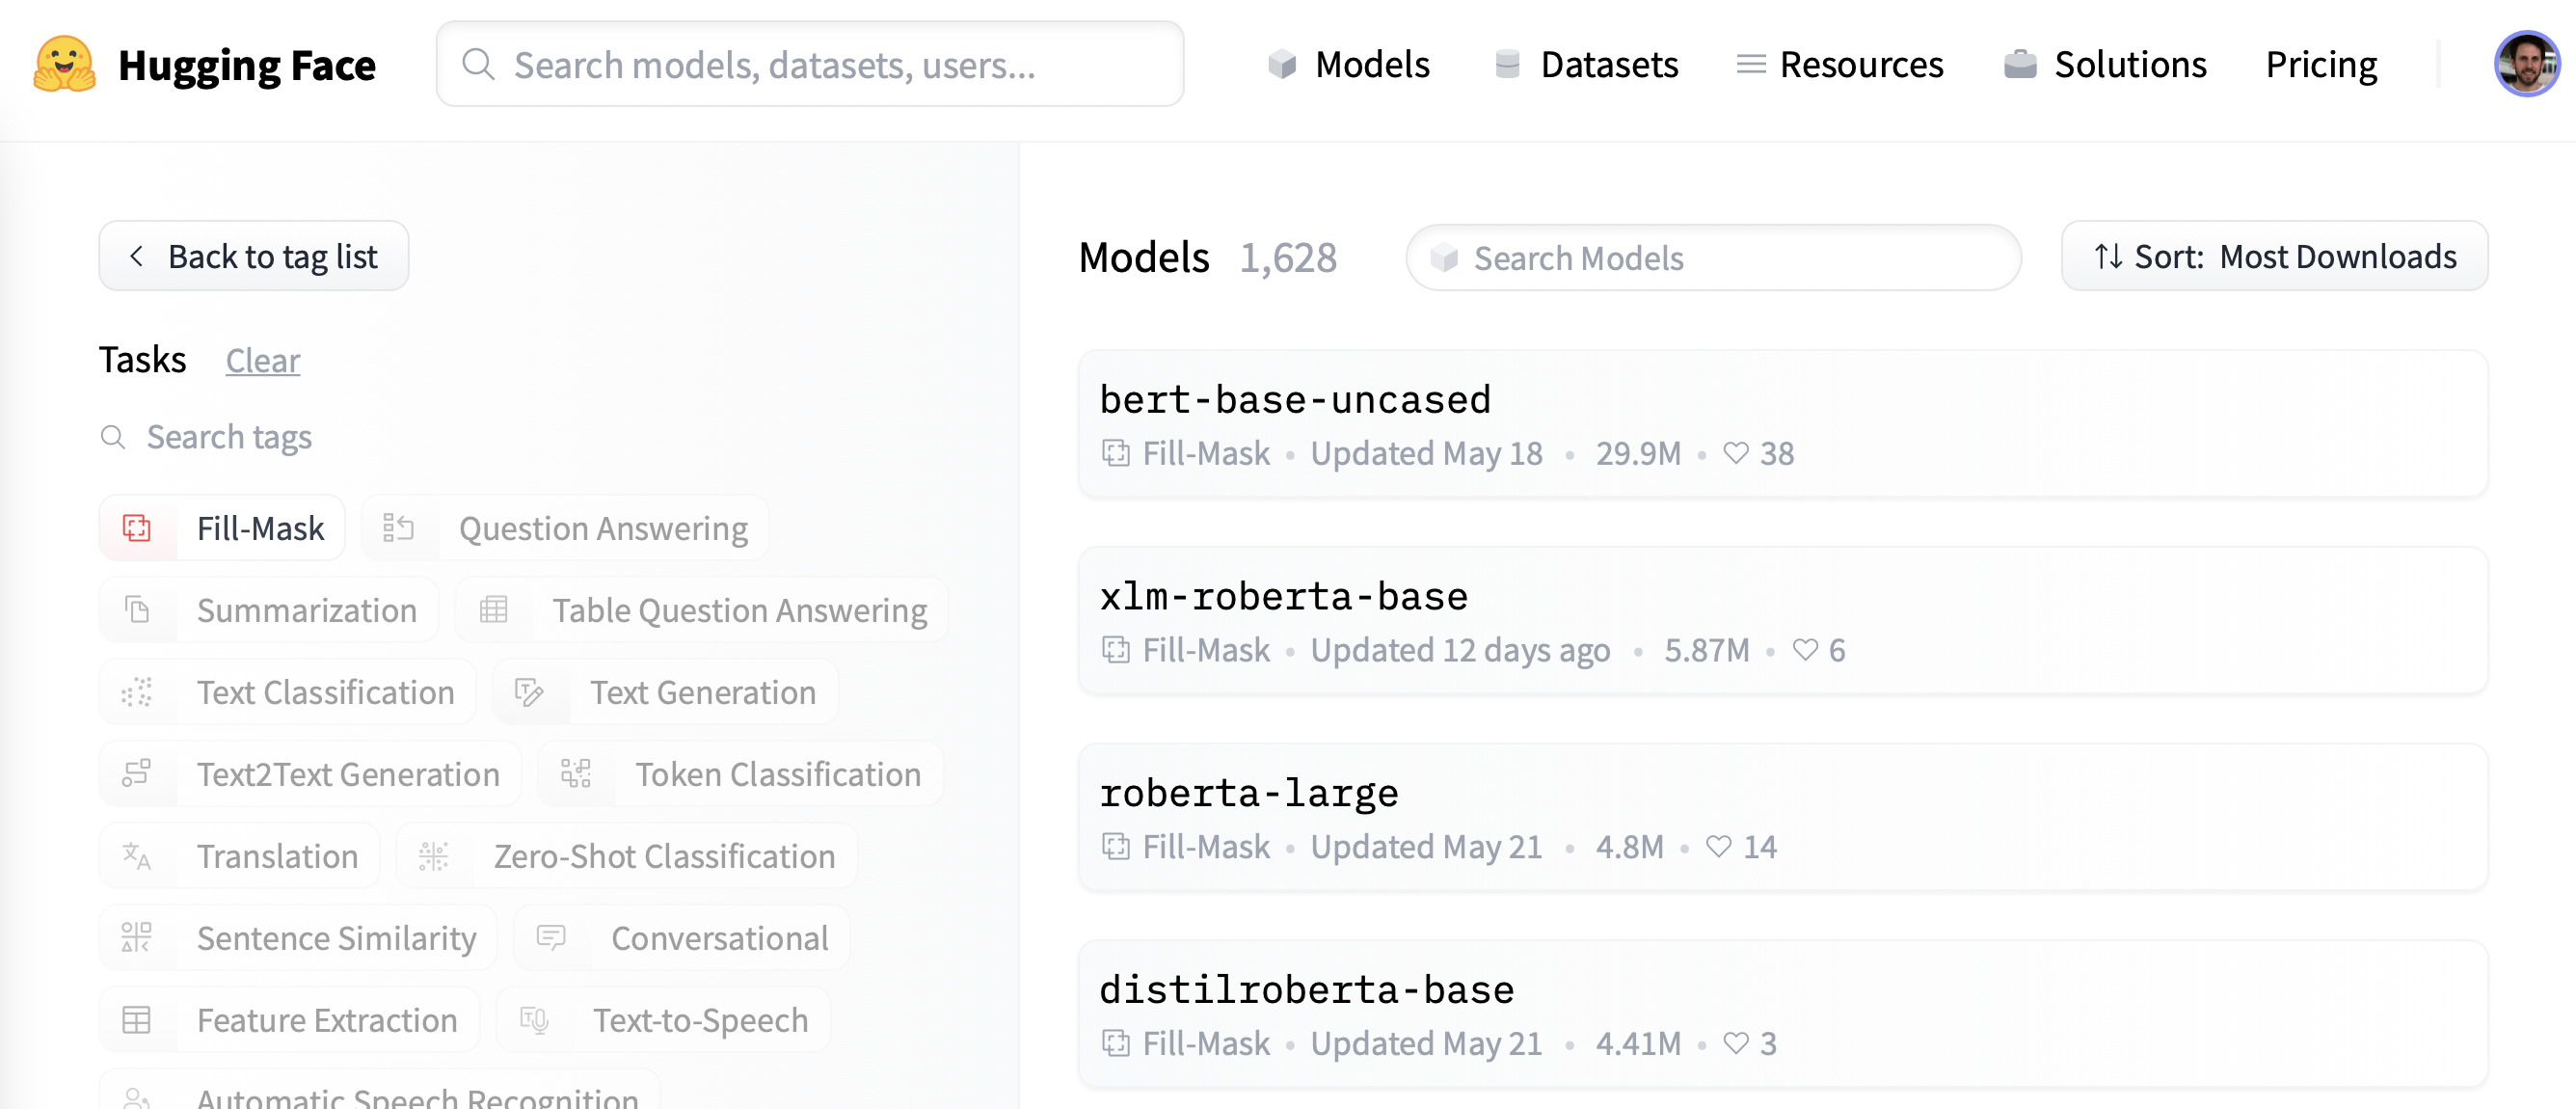

Although the BERT and RoBERTa family of models are the most downloaded, we’ll use a model called DistilBERT that can be trained much faster with little to no loss in downstream performance. This model was trained using a special technique called knowledge distillation, where a large “teacher model” like BERT is used to guide the training of a “student model” that has far fewer parameters. An explanation of the details of knowledge distillation would take us too far afield in this section.

Let’s go ahead and download `DistilBERT` using the `AutoModelForMaskedLM` class:

In [27]:
from transformers import AutoModelForMaskedLM

model_checkpoint = "distilbert-base-uncased"
model = AutoModelForMaskedLM.from_pretrained(model_checkpoint)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

We can see how many parameters this model has by calling the `num_parameters()` method:

In [28]:
distilbert_num_parameters = model.num_parameters() / 1_000_000
print(f"'>>> DistilBERT number of parameters: {round(distilbert_num_parameters)}M'")
print(f"'>>> BERT number of parameters: 110M'")

'>>> DistilBERT number of parameters: 67M'
'>>> BERT number of parameters: 110M'


With around 67 million parameters, DistilBERT is approximately two times smaller than the BERT base model, which roughly translates into a two-fold speedup in training — nice! Let’s now see what kinds of tokens this model predicts are the most likely completions of a small sample of text:

In [29]:
text = "This is a great [MASK]."

As humans, we can imagine many possibilities for the `[MASK]` token, such as “day”, “ride”, or “painting”. For pretrained models, the predictions depend on the corpus the model was trained on, since it learns to pick up the statistical patterns present in the data. Like BERT, DistilBERT was pretrained on the English Wikipedia and BookCorpus datasets, so we expect the predictions for `[MASK]` to reflect these domains. To predict the mask we need DistilBERT’s tokenizer to produce the inputs for the model, so let’s download that from the Hub as well:

In [30]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

With a tokenizer and a model, we can now pass our text example to the model, extract the logits, and print out the top 5 candidates:

In [31]:
import torch

inputs = tokenizer(text, return_tensors="pt")
token_logits = model(**inputs).logits

# Find the location of [MASK] and extract its logits
mask_token_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]
mask_token_logits = token_logits[0, mask_token_index, :]

# Pick the [MASK] candidates with the highest logits
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

for token in top_5_tokens:
    print(f"'>>> {text.replace(tokenizer.mask_token, tokenizer.decode([token]))}'")

'>>> This is a great deal.'
'>>> This is a great success.'
'>>> This is a great adventure.'
'>>> This is a great idea.'
'>>> This is a great feat.'


We can see from the outputs that the model’s predictions refer to everyday terms, which is perhaps not surprising given the foundation of English Wikipedia. Let’s see how we can change this domain to something a bit more niche — highly polarized movie reviews!

## The dataset

To showcase domain adaptation, we’ll use the famous **Large Movie Review Dataset** (or IMDb for short), which is a corpus of movie reviews that is often used to benchmark sentiment analysis models. By fine-tuning DistilBERT on this corpus, we expect the language model will adapt its vocabulary from the factual data of Wikipedia that it was pretrained on to the more subjective elements of movie reviews.

For example `DistilBERT` trained on **Wikipedia** knows the word `"terrible"` in a factual, neutral context. But in movie reviews `"terrible"` appears constantly in emotional, opinionated contexts alongside words like "acting", "plot", "waste of money".

So the model **adjusts its internal weights** to better understand that context. The vocabulary list itself doesn't change — `"terrible"` was already a token before. What changes is the model's sense of how that word is used.

We can get the data from the Hugging Face Hub with the `load_dataset()` function from 🤗 Datasets:

In [32]:
from datasets import load_dataset

imdb_dataset = load_dataset("stanfordnlp/imdb")
imdb_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

We can see that the `train` and `test` splits each consist of 25,000 reviews, while there is an unlabeled split called `unsupervised` that contains 50,000 reviews. Let’s take a look at a few samples to get an idea of what kind of text we’re dealing with. As we’ve done in previous chapters of the course, we’ll chain the `Dataset.shuffle()` and `Dataset.select()` functions to create a random sample:

In [33]:
sample = imdb_dataset["train"].shuffle(seed=42).select(range(3))

for row in sample:
    print(f"\n'>>> Review: {row['text']}'")
    print(f"'>>> Label: {row['label']}'")


'>>> Review: There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks American but, on the other hand, arguing they prefer American series (!!!). Maybe it's the language, or the spirit, but I think this series is more English than American. By the way, the actors are really good and funny. The acting is not superficial at all...'
'>>> Label: 1'

'>>> Review: This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stu

Although we won’t need the labels for language modeling, we can already see that a `0` denotes a negative review, while a `1` corresponds to a positive one.

Now that we’ve had a quick look at the data, let’s dive into preparing it for masked language modeling. As we’ll see, there are some additional steps that one needs to take compared to the sequence classification tasks we saw in Chapter 3. Let’s go!

## Preprocessing the data

For both auto-regressive and masked language modeling, a common preprocessing step is to concatenate all the examples and then split the whole corpus into chunks of equal size. This is quite different from our usual approach, where we simply tokenize individual examples. Why concatenate everything together? The reason is that individual examples might get truncated if they’re too long, and that would result in losing information that might be useful for the language modeling task!

So to get started, we’ll first tokenize our corpus as usual, but without setting the `truncation=True` option in our tokenizer. We’ll also grab the word IDs if they are available ((which they will be if we’re using a fast tokenizer, as described in Chapter 6), as we will need them later on to do whole word masking. We’ll wrap this in a simple function, and while we’re at it we’ll remove the `text` and `label` columns since we don’t need them any longer:

In [34]:
def tokenize_function(examples):
    result = tokenizer(examples["text"])
    if tokenizer.is_fast:
        result["word_ids"] = [result.word_ids(i) for i in range(len(result["input_ids"]))]
    return result

# Use batched=True to activate fast multithreading!
tokenized_datasets = imdb_dataset.map(
    tokenize_function, batched=True, remove_columns=["text", "label"]
)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids'],
        num_rows: 50000
    })
})

**word_ids(i) :-**

Since we use `batched=True`, tokenizer processes multiple sentences at once. So `result` contains a batch of sentences, not just one. `i` specifies which sentence in that batch you want word_ids for.

```python
examples["text"] = [
    "I love NLP",       # sentence 0
    "Great movie",      # sentence 1
    "Terrible acting"   # sentence 2
]

result.word_ids(0)  # → word ids for "I love NLP"
result.word_ids(1)  # → word ids for "Great movie"
result.word_ids(2)  # → word ids for "Terrible acting"
```

Each call returns a list mapping every token back to its original word index:

```python
result.word_ids(0)  →  [None, 0, 1, 2, 2, None]
#                        CLS  I  love N ##LP SEP
# None = special tokens
# 2,2 = both tokens came from same original word "NLP"
```

Since DistilBERT is a BERT-like model, we can see that the encoded texts consist of the `input_ids` and `attention_mask` that we’ve seen in other chapters, as well as the `word_ids` we added.

Now that we’ve tokenized our movie reviews, the next step is to group them all together and split the result into chunks. But how big should these chunks be? This will ultimately be determined by the amount of GPU memory that you have available, but a good starting point is to see what the model’s maximum context size is. This can be inferred by inspecting the `model_max_length` attribute of the tokenizer:

**Firstly let's understand what's going on :-**

This section is about **masked language modeling** (predicting missing words), not classification. So we're not dealing with labeled data, just raw text.

---

**The problem:**

Movie reviews are all different lengths. Some are 50 tokens, some are 600 tokens. The model has a maximum input size (like 512 tokens for BERT). You can't just feed in whatever length you want.

So what we do:

```
review 1: 200 tokens  ─┐
review 2: 400 tokens   ├─ concatenate everything → one long sequence
review 3: 150 tokens  ─┘    [tok1, tok2, tok3, ........., tok750]

then split into equal chunks of 128:
chunk 1: [tok1 → tok128]
chunk 2: [tok129 → tok256]
chunk 3: [tok257 → tok384]
...
```

Every chunk is the same size, fits in the model, no padding wasted.

---

**Why concatenate first instead of just truncating each review?**

Truncating wastes data. A 400 token review truncated to 128 throws away 272 tokens. Concatenating and rechunking uses every single token.

---

**WAIT! Isnt' it contradicting? Here -> tok129 → tok256 what if the tokens from 129 till 200 was of positive review and after it till 256 negative review then both reviews will be mixed and model get's confused about positive and negative review...**

Well we are **not doing classification**. That's why it doesn't matter!

This is **masked language modeling** — the task is just:

```
input:  "I [MASK] this movie"
predict: "loved"
```

No labels like positive/negative. The model is just learning to predict missing words. So it doesn't care if chunk 2 contains the end of a positive review and the start of a negative one — it's not trying to classify anything, just predict masked tokens.

---

So the chunks don't need to be "one review = one chunk". They're just random windows of text for the model to practice predicting words on.

---

If we were doing **classification** — our concern would be 100% valid and we'd never concatenate like this. Each input would be one review with its own label.

But here the task is different so it's fine.

In [35]:
tokenizer.model_max_length

512

This value is derived from the `tokenizer_config.json` file associated with a checkpoint; in this case we can see that the context size is 512 tokens, just like with BERT.

So, in order to run our experiments on GPUs like those found on Google Colab, we’ll pick something a bit smaller that can fit in memory:

In [36]:
chunk_size = 128

> Note that using a small chunk size can be detrimental in real-world scenarios, so you should use a size that corresponds to the use case you will apply your model to.

Now comes the fun part. To show how the concatenation works, let’s take a few reviews from our tokenized training set and print out the number of tokens per review:

In [37]:
# Slicing produces a list of lists for each feature
tokenized_samples = tokenized_datasets["train"][:3]

for idx, sample in enumerate(tokenized_samples["input_ids"]):
    print(f"'>>> Review {idx} length: {len(sample)}'")

'>>> Review 0 length: 363'
'>>> Review 1 length: 304'
'>>> Review 2 length: 133'


We can then concatenate all these examples with a simple dictionary comprehension, as follows:

In [38]:
concatenated_examples = {
    k: sum(tokenized_samples[k], []) for k in tokenized_samples.keys()
}

total_length = len(concatenated_examples["input_ids"])
print(f"'>>> Concatenated reviews length: {total_length}'")

'>>> Concatenated reviews length: 800'


Great, the total length checks out — so now let’s split the concatenated reviews into chunks of the size given by `chunk_size`. To do so, we iterate over the features in `concatenated_examples` and use a list comprehension to create slices of each feature. The result is a dictionary of chunks for each feature:

In [39]:
chunks = {
    k: [t[i : i + chunk_size] for i in range(0, total_length, chunk_size)]
    for k, t in concatenated_examples.items()
}

for chunk in chunks["input_ids"]:
    print(f"'>>> Chunk length: {len(chunk)}'")

'>>> Chunk length: 128'
'>>> Chunk length: 128'
'>>> Chunk length: 128'
'>>> Chunk length: 128'
'>>> Chunk length: 128'
'>>> Chunk length: 128'
'>>> Chunk length: 32'


As you can see in this example, the last chunk will generally be smaller than the maximum chunk size. There are two main strategies for dealing with this:

* Drop the last chunk if it’s smaller than `chunk_size`.

* Pad the last chunk until its length equals `chunk_size`.

We’ll take the first approach here, so let’s wrap all of the above logic in a single function that we can apply to our tokenized datasets:

In [40]:
def group_texts(examples):

    # Concatenate all texts
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}

    # Compute length of concatenated texts
    total_length = len(concatenated_examples[list(examples.keys())[0]])

    # We drop the last chunk if it's smaller than chunk_size
    total_length = (total_length // chunk_size) * chunk_size

    # Split by chunks of max_len
    result = {
        k: [t[i : i + chunk_size] for i in range(0, total_length, chunk_size)]
        for k, t in concatenated_examples.items()
    }
    
    # Create a new labels column
    result["labels"] = result["input_ids"].copy()
    return result

**Why we added extra column called labels and put the same value in it as input_ids here: result["labels"] = result["input_ids"].copy()**

They look the same now but they **won't stay the same** — labels get masked later.

For masked language modeling the training works like:

```python
input_ids:  [101, 1045, 103, 2293, 102]  # 103 = [MASK] token, model sees this
labels:     [101, 1045, 2293, 2293, 102] # original token, model predicts this
```

So the flow is:
1. Copy `input_ids` into `labels` ← this line
2. Later, randomly replace some `input_ids` tokens with `[MASK]`
3. `labels` stays unchanged (original tokens)
4. Model sees masked `input_ids`, tries to predict original `labels`

---

If you didn't have a separate `labels` column and just masked `input_ids` directly, you'd lose the original tokens and the model would have nothing to learn from.

So right now they're identical — but `labels` is saved as the "answer key" before the masking happens to `input_ids`.

Let’s now apply `group_texts()` to our tokenized datasets using our trusty `Dataset.map()` function:

In [41]:
lm_datasets = tokenized_datasets.map(group_texts, batched=True)
lm_datasets

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 61291
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 59904
    })
    unsupervised: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 122957
    })
})

You can see that grouping and then chunking the texts has produced many more examples than our original 25,000 for the train and test splits. That’s because we now have examples involving contiguous tokens that span across multiple examples from the original corpus.

Because of the chunking.

Originally 25,000 reviews each became 1 example. After concatenating and rechunking into 128 token chunks, each review gets split into multiple chunks — each chunk becomes its own example.

```
review 1: 512 tokens → 4 chunks of 128 → 4 examples
review 2: 384 tokens → 3 chunks of 128 → 3 examples
review 3: 256 tokens → 2 chunks of 128 → 2 examples
```

So 25,000 reviews become 61,291 examples because on average each review produced ~2.4 chunks.

---

And that's exactly what the course means by "contiguous tokens spanning multiple examples" — chunk 2 of review 1 and chunk 1 of review 2 might end up mixed together in one chunk, so you'll see `[SEP]` (end of review 1) followed by `[CLS]` (start of review 2) inside the same chunk.

You can see this explicitly by looking for the special [SEP] and [CLS] tokens in one of the chunks:

In [42]:
tokenizer.decode(lm_datasets["train"][1]["input_ids"])

"as the vietnam war and race issues in the united states. in between asking politicians and ordinary denizens of stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men. < br / > < br / > what kills me about i am curious - yellow is that 40 years ago, this was considered pornographic. really, the sex and nudity scenes are few and far between, even then it ' s not shot like some cheaply made porno. while my countrymen mind find it shocking, in reality sex and nudity are a major staple in swedish cinema. even ingmar bergman,"

In this example you can see two overlapping movie reviews, one about a high school movie and the other about homelessness. Let’s also check out what the labels look like for masked language modeling:

In [43]:
tokenizer.decode(lm_datasets["train"][1]["labels"])

"as the vietnam war and race issues in the united states. in between asking politicians and ordinary denizens of stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men. < br / > < br / > what kills me about i am curious - yellow is that 40 years ago, this was considered pornographic. really, the sex and nudity scenes are few and far between, even then it ' s not shot like some cheaply made porno. while my countrymen mind find it shocking, in reality sex and nudity are a major staple in swedish cinema. even ingmar bergman,"

As expected from our `group_texts()` function above, this looks identical to the decoded `input_ids` — but then how can our model possibly learn anything? We’re missing a key step: inserting `[MASK]` tokens at random positions in the inputs! Let’s see how we can do this on the fly during fine-tuning using a special data collator(since all chunks are already equal size (128), padding is unnecessary so DataCollator here will be used only for the masking part, not padding.).

## Fine-tuning DistilBERT with the Trainer API

Fine-tuning a masked language model is almost identical to fine-tuning a sequence classification model, like we did in Chapter 3. The only difference is that we need a special data collator that can randomly mask some of the tokens in each batch of texts. Fortunately, 🤗 Transformers comes prepared with a dedicated `DataCollatorForLanguageModeling` for just this task. We just have to pass it the tokenizer and an `mlm_probability` argument that specifies what fraction of the tokens to mask. We’ll pick 15%, which is the amount used for BERT and a common choice in the literature:

In [44]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm_probability=0.15)

To see how the random masking works, let’s feed a few examples to the data collator. Since it expects a list of `dicts`, where each `dict` represents a single chunk of contiguous text, we first iterate over the dataset before feeding the batch to the collator. We remove the `"word_ids"` key for this data collator as it does not expect it:

In [45]:
samples = [lm_datasets["train"][i] for i in range(2)]
for sample in samples:
    _ = sample.pop("word_ids")

for chunk in data_collator(samples)["input_ids"]:
    print(f"\n'>>> {tokenizer.decode(chunk)}'")


'>>> [CLS] i rented i am curious - yellow from my [MASK] store because of all [MASK] controversy that surrounded it when it was first released in 1967. i also heard that at first it was [MASK] by [MASK]. s. customs if it [MASK] tried to enter this country, therefore being a fan of films considered [MASK]essed [MASK] i really had to see this for myself. < br [MASK] > < br / > the [MASK] is centered around a [MASK] swedish drama student named lena who [MASK] to [MASK] everything she can about [MASK]. in particular [MASK] wants to focus her attentions to making somecule of documentary on what [MASK] average swede loyal [MASK] certain political issues [MASK]'

'>>> as [MASK] vietnam war and race issues [MASK] the united states [MASK] in [MASK] asking politicians and ordinary denizens [MASK] stockholm about their opinions on politics, she has sex with her [MASK] teacher, classmates, and married men. < br / > < br / > what kills me about i am curious [MASK] yellow is that 40 years ago [MASK

Nice, it worked! We can see that the `[MASK]` token has been randomly inserted at various locations in our text. These will be the tokens which our model will have to predict during training — and the beauty of the data collator is that it will randomize the `[MASK]` insertion with every batch!

One side effect of random masking is that our evaluation metrics will not be deterministic when using the `Trainer`, since we use the same data collator for the training and test sets. We’ll see later, when we look at fine-tuning with 🤗 Accelerate, how we can use the flexibility of a custom evaluation loop to freeze the randomness.

It means the masking is random every time.

So when evaluating on the test set, different tokens get masked each run. Which means your evaluation score (perplexity) will be slightly different every time you run it — even on the exact same data.

```
Run 1: "I [MASK] this movie" → model predicts "loved" → score X
Run 2: "I loved [MASK] movie" → model predicts "this" → score Y
# same sentence, different mask, different score
```

---

Ideally evaluation should be **deterministic** — same data should give same score every time so you can reliably compare runs.

The fix is to freeze the random seed or pre-mask the test set once and keep it fixed. But `Trainer` uses the same DataCollator for both train and test, and that collator masks randomly every time — so you can't easily fix it with `Trainer`.

With **Accelerate** you write a custom eval loop where you control everything, so you can fix the masking for evaluation.

When training models for masked language modeling, one technique that can be used is to mask whole words together, not just individual tokens. This approach is called **whole word masking**. If we want to use whole word masking, we will need to build a data collator ourselves. A data collator is just a function that takes a list of samples and converts them into a batch. If we want to build our own data collator then we’ll use the word IDs computed earlier to make a map between word indices and the corresponding tokens, then randomly decide which words to mask and apply that mask on the inputs. Note that the labels are all -100 except for the ones corresponding to mask words.

**What matters from the above paragraph:**

- Whole word masking = mask entire words together instead of random individual tokens
- Labels are `-100` for unmasked tokens — meaning the loss function ignores them, only calculates loss on masked tokens

#### Regular Masking VS Whole Word Masking

With **regular masking** — random individual tokens get masked:

```
"unhappiness" → ["un", "##happy", "##ness"]
randomly mask token 2 only:
input:  ["un", "[MASK]", "##ness"]
```

The model can basically cheat here — it sees "un" and "##ness" and can easily guess "##happy" without really understanding the word. Too easy.

---

With **whole word masking** — if any token of a word gets picked, all tokens of that word get masked:

```
"unhappiness" → ["un", "##happy", "##ness"]
mask the whole word:
input:  ["MASK", "[MASK]", "[MASK]"]
```

Now the model has to understand the surrounding context to predict the whole word. Much harder, forces deeper understanding.

---

So whole word masking = harder task for the model = better contextual understanding = more useful representations learned.

BERT's later versions (like RoBERTa) actually use whole word masking by default for this reason.

Now that we have the data collator, the rest of the fine-tuning steps are standard. Training can take a while depending on the GPU, so we’ll first downsample the size of the training set to a few thousand examples. Don’t worry, we’ll still get a pretty decent language model! A quick way to downsample a dataset in 🤗 Datasets is via the `Dataset.train_test_split()` function that we saw in Chapter 5:

In [46]:
train_size = 10_000
test_size = int(0.1 * train_size)

downsampled_dataset = lm_datasets["train"].train_test_split(
    train_size=train_size, test_size=test_size, seed=42
)
downsampled_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'word_ids', 'labels'],
        num_rows: 1000
    })
})

This has automatically created new `train` and `test` splits, with the training set size set to 10,000 examples and the validation set to 10% of that — feel free to increase this if you have a beefy GPU!

Now we can specify the arguments for the `Trainer`:

In [47]:
from transformers import TrainingArguments

batch_size = 64
# Show the training loss with every epoch
logging_steps = len(downsampled_dataset["train"]) // batch_size
model_name = model_checkpoint.split("/")[-1]

training_args = TrainingArguments(
    output_dir=f"{model_name}-finetuned-imdb",
    eval_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    fp16=True,
    logging_steps=logging_steps,
)

We now have all the ingredients to instantiate the Trainer. Here we use the `data_collator`.

In [49]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=downsampled_dataset["train"],
    eval_dataset=downsampled_dataset["test"],
    data_collator=data_collator,
)

We’re now ready to run `trainer.train()` — but before doing so let’s briefly look at `perplexity`, which is a common metric to evaluate the performance of language models.

## Perplexity for language models

Unlike other tasks like text classification or question answering where we’re given a labeled corpus to train on, with language modeling we don’t have any explicit labels. So how do we determine what makes a good language model? Like with the autocorrect feature in your phone, a good language model is one that assigns high probabilities to sentences that are grammatically correct, and low probabilities to nonsense sentences. To give you a better idea of what this looks like, you can find whole sets of “autocorrect fails” online, where the model in a person’s phone has produced some rather funny (and often inappropriate) completions!

**Perplexity** is a just measure of how "confused" or "surprised" the model is by the text.

Simply put:
- **Low perplexity** → model predicted the text well, it wasn't surprised → good model
- **High perplexity** → model was very surprised by the text → poor model

---

**Where it comes from:**

Perplexity is just `e^loss` (exponential of cross entropy loss). So it's directly derived from the loss — just a more interpretable way to express it.

- Loss of `0` → perplexity of `1` (perfect, model predicted everything correctly)
- Higher loss → higher perplexity → more confused model

---

**Intuitive example:**

If you're predicting the next word and your vocabulary has 30,000 words:
- Perplexity of `30,000` → model is essentially guessing randomly
- Perplexity of `10` → model has narrowed it down to ~10 likely words on average
- Perplexity of `1` → model predicts perfectly every time

So lower perplexity = better language model. It's the standard metric for evaluating language models.

Assuming our test set consists mostly of sentences that are grammatically correct, then one way to measure the quality of our language model is to calculate the probabilities it assigns to the next word in all the sentences of the test set. High probabilities indicates that the model is not “surprised” or “perplexed” by the unseen examples, and suggests it has learned the basic patterns of grammar in the language. There are various mathematical definitions of perplexity, but the one we’ll use defines it as the exponential of the cross-entropy loss. Thus, we can calculate the perplexity of our pretrained model by using the `Trainer.evaluate()` function to compute the cross-entropy loss on the test set and then taking the exponential of the result:

In [50]:
import math

eval_results = trainer.evaluate()
print(f">>> Perplexity: {math.exp(eval_results['eval_loss']):.2f}")

Training Loss,Validation Loss,Epoch
No log,3.088138,0


>>> Perplexity: 21.94


A lower perplexity score means a better language model, and we can see here that our starting model has a somewhat large value. Let’s see if we can lower it by fine-tuning! To do that, we first run the training loop:

In [51]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,2.680623,2.493543
2,2.583533,2.448400
3,2.526031,2.481313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=471, training_loss=2.5962706806806497, metrics={'train_runtime': 361.6903, 'train_samples_per_second': 82.944, 'train_steps_per_second': 1.302, 'total_flos': 994208670720000.0, 'train_loss': 2.5962706806806497, 'epoch': 3.0})

and then compute the resulting perplexity on the test set as before:

In [52]:
eval_results = trainer.evaluate()
print(f">>> Perplexity: {math.exp(eval_results['eval_loss']):.2f}")

Training Loss,Validation Loss,Epoch
2.526031,2.486997,3


>>> Perplexity: 12.03


Nice — this is quite a reduction in perplexity, which tells us the model has learned something about the domain of movie reviews!

In our use case we didn’t need to do anything special with the training loop, but in some cases you might need to implement some custom logic. For these applications, you can use 🤗 `Accelerate` — let’s take a look!

**Accelerate** is a HuggingFace library that handles distributed training across multiple GPUs/TPUs automatically — removing the manual device placement code (`model.to(device)`, `batch.to(device)` etc).

If you're on a single machine then can skip it.

## Using our fine-tuned model

In [67]:
from transformers import pipeline

mask_filler = pipeline(
    "fill-mask", 
    model="distilbert-base-uncased-finetuned-imdb\checkpoint-471",  # your local output directory
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

We can then feed the pipeline our sample text of “This is a great [MASK]” and see what the top 5 predictions are:

In [65]:
preds = mask_filler(text)

for pred in preds:
    print(f">>> {pred['sequence']}")

>>> this is a great film.
>>> this is a great movie.
>>> this is a great idea.
>>> this is a great deal.
>>> this is a great one.


Neat — our model has clearly adapted its weights to predict words that are more strongly associated with movies!

This wraps up our first experiment with training a language model.

> Similarly, Translation, Summarization & Question Answering models can be fine-tuned as well.

# Training a causal language model from scratch :-

Up until now, we’ve mostly been using pretrained models and fine-tuning them for new use cases by reusing the weights from pretraining. As we saw in Chapter 1, this is commonly referred to as **transfer learning**, and it’s a very successful strategy for applying Transformer models to most real-world use cases where labeled data is sparse. In this chapter, we’ll take a different approach and train a completely new model from scratch. This is a good approach to take if you have a lot of data and it is very different from the pretraining data used for the available models. However, it also requires considerably more compute resources to pretrain a language model than just to fine-tune an existing one. Examples where it can make sense to train a new model include for datasets consisting of musical notes, molecular sequences such as DNA, or programming languages. The latter have recently gained traction thanks to tools such as TabNine and GitHub’s Copilot, powered by OpenAI’s Codex model, that can generate long sequences of code. This task of text generation is best addressed with auto-regressive or causal language models such as GPT-2.

In this section we will build a scaled-down version of a code generation model: we’ll focus on one-line completions instead of full functions or classes, using a subset of Python code. When working with data in Python you are in frequent contact with the Python data science stack, consisting of the `matplotlib`, `seaborn`, `pandas`, and `scikit-learn` libraries. When using those frameworks it’s common to need to look up specific commands, so it would be nice if we could use a model to complete these calls for us.

In Chapter 6 we created an efficient tokenizer to process Python source code, but what we still need is a large-scale dataset to pretrain a model on. Here, we’ll apply our tokenizer to a corpus of Python code derived from GitHub repositories. We will then use the `Trainer` API and 🤗 Accelerate to train the model. Let’s get to it!

Note that since there is some randomization happening in the text generation, you will probably get a slightly different result.

## Gathering the data

Python code is abundantly available from code repositories such as GitHub, which we can use to create a dataset by scraping for every Python repository. This was the approach taken in the **Transformers textbook** to pretrain a large GPT-2 model. Using a GitHub dump of about 180 GB containing roughly 20 million Python files called `codeparrot`, the authors built a dataset that they then shared on the **Hugging Face Hub**.

However, training on the full corpus is time- and compute-consuming, and we only need the subset of the dataset concerned with the Python data science stack. So, let’s start by filtering the `codeparrot` dataset for all files that include any of the libraries in this stack. Because of the dataset’s size, we want to avoid downloading it; instead, we’ll use the streaming feature to filter it on the fly. To help us filter the code samples using the libraries we mentioned earlier, we’ll use the following function:

In [1]:
def any_keyword_in_string(string, keywords):
    for keyword in keywords:
        if keyword in string:
            return True
    return False

In [2]:
# Let's test on 2 examples:

filters = ["pandas", "sklearn", "matplotlib", "seaborn"]
example_1 = "import numpy as np"
example_2 = "import pandas as pd"

print(
    any_keyword_in_string(example_1, filters), any_keyword_in_string(example_2, filters)
)

False True


We can use this to create a function that will stream the dataset and filter the elements we want:

In [3]:
from collections import defaultdict
from tqdm import tqdm
from datasets import Dataset

def filter_streaming_dataset(dataset, filters):
    filtered_dict = defaultdict(list)
    total = 0
    for sample in tqdm(iter(dataset)):
        total += 1
        if any_keyword_in_string(sample["content"], filters):
            for k, v in sample.items():
                filtered_dict[k].append(v)
                
    print(f"{len(filtered_dict['content'])/total:.2%} of data after filtering.")
    return Dataset.from_dict(filtered_dict)

Then we can simply apply this function to the streaming dataset:

In [ ]:
# This cell will take a very long time to execute, so you should skip it and go to the next one!

# from datasets import load_dataset

# split = "train"  # "valid"
# filters = ["pandas", "sklearn", "matplotlib", "seaborn"]

# data = load_dataset(f"transformersbook/codeparrot-{split}", split=split, streaming=True)
# filtered_data = filter_streaming_dataset(data, filters)

This leaves us with about 3% of the original dataset, which is still quite sizable — the resulting dataset is 6 GB and consists of 600,000 Python scripts!

Filtering the full dataset can take 2-3h depending on your machine and bandwidth. If you don’t want to go through this lengthy process yourself, we provide the filtered dataset on the Hub for you to download:

In [4]:
from datasets import load_dataset, DatasetDict

ds_train = load_dataset("huggingface-course/codeparrot-ds-train", split="train")
ds_valid = load_dataset("huggingface-course/codeparrot-ds-valid", split="validation")

raw_datasets = DatasetDict(
    {
        "train": ds_train,  # .shuffle().select(range(50000)),
        "valid": ds_valid,  # .shuffle().select(range(500))
    }
)

raw_datasets

DatasetDict({
    train: Dataset({
        features: ['repo_name', 'path', 'copies', 'size', 'content', 'license'],
        num_rows: 606720
    })
    valid: Dataset({
        features: ['repo_name', 'path', 'copies', 'size', 'content', 'license'],
        num_rows: 3322
    })
})

Let’s look at an example from the dataset. We’ll just see the first 200 characters of each field:

In [5]:
for key in raw_datasets["train"][0]:
    print(f"{key.upper()}: {raw_datasets['train'][0][key][:200]}")

REPO_NAME: kmike/scikit-learn
PATH: sklearn/utils/__init__.py
COPIES: 3
SIZE: 10094
CONTENT: """
The :mod:`sklearn.utils` module includes various utilites.
"""

from collections import Sequence

import numpy as np
from scipy.sparse import issparse
import warnings

from .murmurhash import murm
LICENSE: bsd-3-clause


We can see that the `content` field contains the code that we want our model to train on. Now that we have a dataset, we need to prepare the texts so they’re in a format suitable for pretraining.

## Preparing the dataset

The first step will be to tokenize the data, so we can use it for training. Since our goal is to mainly autocomplete short function calls, we can keep the context size relatively small. This has the benefit that we can train the model much faster and it requires significantly less memory. If it is important for your application to have more context (for example, if you want the model to write unit tests based on a file with the function definition), make sure you increase that number, but also keep in mind that this comes with a greater GPU memory footprint. For now, let’s fix the context size at 128 tokens, as opposed to the 1,024 or 2,048 used in GPT-2 or GPT-3, respectively.

Most documents contain many more than 128 tokens, so simply truncating the inputs to the maximum length would eliminate a large fraction of our dataset. Instead, we’ll use the `return_overflowing_tokens` option to tokenize the whole input and split it into several chunks, as we did in Chapter 6. We’ll also use the `return_length` option to return the length of each created chunk automatically. Often the last chunk will be smaller than the context size, and we’ll get rid of these pieces to avoid padding issues; we don’t really need them as we have plenty of data anyway.

Let’s see exactly how this works by looking at the first two examples:

In [6]:
from transformers import AutoTokenizer

context_length = 128
tokenizer = AutoTokenizer.from_pretrained("huggingface-course/code-search-net-tokenizer")

outputs = tokenizer(
    raw_datasets["train"][:2]["content"],
    truncation=True,
    max_length=context_length,
    return_overflowing_tokens=True,
    return_length=True,
)

print(f"Input IDs length: {len(outputs['input_ids'])}")
print(f"Input chunk lengths: {(outputs['length'])}")
print(f"Chunk mapping: {outputs['overflow_to_sample_mapping']}")

Input IDs length: 34
Input chunk lengths: [128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 117, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 128, 41]
Chunk mapping: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


We can see that we get 34 segments in total from those two examples. Looking at the chunk lengths, we can see that the chunks at the ends of both documents have less than 128 tokens (117 and 41, respectively). These represent just a small fraction of the total chunks that we have, so we can safely throw them away. With the `overflow_to_sample_mapping` field, we can also reconstruct which chunks belonged to which input samples.

With this operation we’re using a handy feature of the `Dataset.map()` function in 🤗 Datasets, which is that it does not require one-to-one maps; as we saw in section 3, we can create batches with more or fewer elements than the input batch. This is useful when doing operations like data augmentation or data filtering that change the number of elements. In our case, when tokenizing each element into chunks of the specified context size, we create many samples from each document. We just need to make sure to delete the existing columns, since they have a conflicting size. If we wanted to keep them, we could repeat them appropriately and return them within the `Dataset.map()` call:

In [7]:
def tokenize(element):
    outputs = tokenizer(
        element["content"],
        truncation=True,
        max_length=context_length,
        return_overflowing_tokens=True,
        return_length=True,
    )
    input_batch = []
    for length, input_ids in zip(outputs["length"], outputs["input_ids"]):
        if length == context_length:
            input_batch.append(input_ids)
    return {"input_ids": input_batch}

tokenized_datasets = raw_datasets.map(
    tokenize, batched=True, remove_columns=raw_datasets["train"].column_names
)
tokenized_datasets

Map:   0%|          | 0/606720 [00:00<?, ? examples/s]

Map:   0%|          | 0/3322 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 16702061
    })
    valid: Dataset({
        features: ['input_ids'],
        num_rows: 93164
    })
})

Took nearly 100 Minutes to complete so let's save it so that we can use it directly next time!

In [ ]:
tokenized_datasets.save_to_disk("tokenized_codeparrot")

In [1]:
from datasets import load_from_disk

tokenized_datasets = load_from_disk("tokenized_codeparrot")

Loading dataset from disk:   0%|          | 0/18 [00:00<?, ?it/s]

In [12]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 16702061
    })
    valid: Dataset({
        features: ['input_ids'],
        num_rows: 93164
    })
})

We now have 16.7 million examples with 128 tokens each, which corresponds to about 2.1 billion tokens in total. For reference, OpenAI’s GPT-3 and Codex models are trained on 300 and 100 billion tokens, respectively, where the Codex models are initialized from the GPT-3 checkpoints. Our goal in this section is not to compete with these models, which can generate long, coherent texts, but to create a scaled-down version providing a quick autocomplete function for data scientists.

Now that we have the dataset ready, let’s set up the model!

> `✏️ Note:` Getting rid of all the chunks that are smaller than the context size wasn’t a big issue here because we’re using small context windows. As you increase the context size (or if you have a corpus of short documents), the fraction of chunks that are thrown away will also grow. A more efficient way to prepare the data is to join all the tokenized samples in a batch with an `eos_token_id` token in between, and then perform the chunking on the concatenated sequences. For that we will have to modify the `tokenize()` function to make use of that approach. Note that you’ll want to set `truncation=False` and remove the other arguments from the tokenizer to get the full sequence of token IDs.

## Initializing a new model

Our first step is to freshly initialize a GPT-2 model. We’ll use the same configuration for our model as for the small GPT-2 model, so we load the pretrained configuration, make sure that the tokenizer size matches the model vocabulary size and pass the `bos` and `eos` (beginning and end of sequence) token IDs:

**AutoConfig** loads the **architecture configuration** of a model — things like number of layers, attention heads, hidden size, vocab size etc — without loading the actual weights.

`Architecture`: It is basically all the structural decisions about how the model is built like: Number of layers, Hidden size, Context length, Activation functions etc

So `AutoConfig.from_pretrained("gpt2")` loads GPT-2's architecture settings (how many layers, how big etc) but **no weights** — just the blueprint.

In [2]:
from transformers import AutoTokenizer, GPT2LMHeadModel, AutoConfig

tokenizer = AutoTokenizer.from_pretrained("huggingface-course/code-search-net-tokenizer")
context_length = 128

config = AutoConfig.from_pretrained(
    "gpt2",
    vocab_size=len(tokenizer),   #  match our custom tokenizer's vocabulary size
    n_ctx=context_length,    # set the context window size (128 in our case)
    bos_token_id=tokenizer.bos_token_id,   # tell the model which tokens mark beginning
    eos_token_id=tokenizer.eos_token_id,   # end of sequence
)

**Why not using the gp2's tokenizer?**

We have been using the same tokenizer as of the model we load but we won't do that here because this time we're training **from scratch on Python code** — not fine-tuning a pretrained model.

Remember back in Chapter 6 we trained a **custom tokenizer** on the **CodeSearchNet dataset** specifically for Python code. That tokenizer (`huggingface-course/code-search-net-tokenizer`) was trained to split Python code more efficiently than GPT-2's original tokenizer.

With that configuration, we can load a new model. Note that this is the first time we don’t use the `from_pretrained()` function, since we’re actually initializing a model ourself.

**How it's different from `from_pretrained`?**

Exactly the difference:

- **`AutoModel.from_pretrained("gpt2")`** → loads architecture + **pretrained weights** (the learned 117M parameters from OpenAI's training)

- **`AutoConfig.from_pretrained("gpt2")`** → loads **only the architecture blueprint**, no weights at all

Then `GPT2LMHeadModel(config)` creates a model with that blueprint but **random weights** — essentially a brand new untrained model with GPT-2's structure.

---

We're doing this because we want to train from **scratch** — we don't want OpenAI's pretrained weights, we want a fresh model that will learn only from your Python code dataset. So we borrow GPT-2's architecture design but start with random weights.

In [ ]:
# This creates a fresh GPT-2 model from scratch using that config — random weights, same architecture as GPT-2 but with your custom settings. No pretrained weights loaded.
model = GPT2LMHeadModel(config)

model_size = sum(t.numel() for t in model.parameters())
print(f"GPT-2 size: {model_size/1000**2:.1f}M parameters")

GPT-2 size: 124.2M parameters


Our model has 124M parameters that we’ll have to tune. Before we can start training, we need to set up a data collator that will take care of creating the batches. We can use the `DataCollatorForLanguageModeling` collator, which is designed specifically for language modeling (as the name subtly suggests). Besides stacking and padding batches, it also takes care of creating the language model labels — in causal language modeling the inputs serve as labels too (just shifted by one element), and this data collator creates them on the fly during training so we don’t need to duplicate the `input_ids`.

**Let's Understand Properly:**

Causal language modeling = predicting the next word. So the label for each token is just the next token in the sequence.

```
input:  ["I", "love", "NLP", "very"]
labels: ["love", "NLP", "very", "much"]
```

See how labels is just input shifted by one position to the right? The label for "I" is "love", label for "love" is "NLP" etc.

Note that `DataCollatorForLanguageModeling` supports both masked language modeling (MLM) and causal language modeling (CLM). By default it prepares data for MLM(Randomly masks some percent of tokens with [MASK]
& Sets labels to original tokens for masked positions, -100 for rest), but we can switch to CLM by setting the argument `mlm=False`:

In [4]:
from transformers import DataCollatorForLanguageModeling

tokenizer.pad_token = tokenizer.eos_token   # telling to use the eos_token (end of sequence token) as the pad token instead
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)

Let’s have a look at an example:

In [5]:
out = data_collator([tokenized_datasets["train"][i] for i in range(5)])
for key in out:
    print(f"{key} shape: {out[key].shape}")

input_ids shape: torch.Size([5, 128])
attention_mask shape: torch.Size([5, 128])
labels shape: torch.Size([5, 128])


We can see that the examples have been stacked and all the tensors have the same shape. Note the `attention_mask` and `labels` column got created by the `DataCollatorForLanguageModeling` when creating the batch.

**Recalling `attention_mask`**

Different thing from self attention.

**Attention mask** is just a simple binary mask that tells the model which tokens are real and which are padding:

```
input_ids:      [101, 1045, 2293, 0,   0  ]
attention_mask: [1,   1,    1,    0,   0  ]
# 1 = real token, pay attention to this
# 0 = padding, ignore this
```

So the model doesn't waste computation attending to padding tokens.

> ⚠️ Shifting the inputs and labels to align them happens inside the model, so the data collator just copies the inputs to create the labels.

Now we have everything in place to actually train our model.

All that’s left to do is configure the training arguments and fire up the `Trainer`. We’ll use a cosine learning rate schedule with some warmup and an effective batch size of 256 (`per_device_train_batch_size * gradient_accumulation_steps`). Gradient accumulation is used when a single batch does not fit into memory, and incrementally builds up the gradient through several forward/backward passes.

#### Let's understand what the above para means:**

**Cosine learning rate schedule:**

Instead of keeping learning rate constant or dropping it linearly, it follows a cosine curve:

```
high → slowly decreases → very low → (looks like half a cosine wave)
```

Why? Starts learning fast, gradually slows down as training progresses so it doesn't overshoot the optimal weights near the end. Works better in practice than constant LR.

**Warmup** = learning rate starts from 0, ramps up first before following the cosine decay. Prevents unstable updates at the very beginning of training.

---

**Why single batch might not fit in memory:**

Batch size 256 means 256 sequences of 128 tokens each all loaded into GPU simultaneously. That's a lot of tensors, activations, gradients all stored at once. A single consumer GPU (8-16GB VRAM) might not handle that.

---

**Gradient accumulation:**

Workaround for limited GPU memory. Instead of one batch of 256:

```
# Split into 8 smaller batches of 32
batch 1 of 32 → forward + backward → accumulate gradients, don't update yet
batch 2 of 32 → forward + backward → accumulate gradients, don't update yet
...
batch 8 of 32 → forward + backward → NOW update weights

# effect is same as one batch of 256
```

So:
```
effective_batch_size = per_device_train_batch_size * gradient_accumulation_steps
256 = 32 * 8
```

Same result as batch 256, but only 32 sequences in memory at once.

**Why we even use gradient accumulation tho?**

The only main reason of using it is that: choosing larger batch size gives better gradient results.

```
large batch → more samples per gradient update → more stable/accurate gradient → better training
```

But large batch doesn't fit in VRAM. So gradient accumulation fakes it:

```
# Instead of one batch of 256 (doesn't fit in low VRAM[example 6GB])
# Do 32 mini batches of 8 (each fits in 6GB)
# Accumulate gradients across all 32
# Then update weights once
# = mathematically same as batch 256
```

Same result, fraction of the VRAM.

**Recalling `gradient`**

Remember **backpropagation!** After forward pass, you calculate loss, then backprop computes how much each weight contributed to that loss — that "how much" is the gradient.

```
gradient = how much should this weight change to reduce loss
```

It's just a number (derivative) for every single parameter in the model. So 124M parameters = 124M gradients stored in VRAM simultaneously.

In [ ]:
from transformers import Trainer, TrainingArguments

args = TrainingArguments(
    output_dir="codeparrot-ds",   # saves checkpoints in this directory during training
    per_device_train_batch_size=32,   # if VRAM size is not large then better reduce the batch size of train and eval to 16 or even 8 to escape the crash but change the gradient accumulation accordingly so that per_device_train_batch_size * gradient_accumulation_steps should be equal to 256(although 256 is a choice but choosing larger batch size gives better gradient results)
    per_device_eval_batch_size=32,
    evaluation_strategy="steps",
    eval_steps=5_000,   # every 5000 training steps, pause training and run evaluation on the validation set. Just controls how often you check the model's performance
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    weight_decay=0.1,
    warmup_steps=1_000,    # ramp up happens over the first 1000 steps & 1_000 is just Python's way of writing 1000 — underscore is just a visual separator for readability, same as how humans write 1,000. Python ignores it completely
    logging_steps=5_000,   # print/log loss every 5000 steps
    lr_scheduler_type="cosine",
    learning_rate=5e-4,
    save_steps=5_000,   # save checkpoint every 5000 steps
    fp16=True,  # mixed precision - switches to 16-bit floating point for numbers,  not everything switches to fp16, just the parts where it's safe to do so.
)

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=args,
    data_collator=data_collator,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["valid"],
)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11088\1408894166.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Now we can just start the `Trainer` and wait for training to finish. Depending on whether you run it on the full or a subset of the training set this will take 20 or 2 hours, respectively.

In [ ]:
trainer.train()

## Code generation with a pipeline

Now is the moment of truth: let’s see how well the trained model actually works! We can see in the logs that the loss went down steadily, but to put the model to the test let’s take a look at how well it works on some prompts. To do that we’ll wrap the model in a text generation `pipeline`, and we’ll put it on the GPU for fast generations if there is one available:

In [16]:
import torch
from transformers import pipeline

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
pipe = pipeline(
    "text-generation", model="huggingface-course/codeparrot-ds", device=device
)

config.json:   0%|          | 0.00/938 [00:00<?, ?B/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--huggingface-course--codeparrot-ds. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/510M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

Device set to use cuda


Let’s start with the simple task of creating a scatter plot:

In [32]:
txt = """\
# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create scatter plot with x, y
"""
print(pipe(txt, num_return_sequences=1)[0]["generated_text"])

# num_return_sequences=1 - How many different completions you want the model to generate for the same input
# pipe() returns a list of dictionaries. One dict per sequence as we set num_return_sequences=1,If we did num_return_sequences=3 we'd get 3 dicts in the list and could do [0], [1], [2] to access each completion

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create scatter plot with x, y
fig = plt.figure(figsize=(10, 10))



The result can be incorrect or incomplete as well depending on the max output token. 

This model was trained on a subset of code data, not the full dataset, and only for 1 epoch. So it makes mistakes. For a properly trained model on full data for more epochs the outputs would be much more consistent and correct.

Does it also work for a `pandas` operation? Let’s see if we can create a `DataFrame` from two arrays:

In [44]:
txt = """\
# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create dataframe from x and y
"""
print(pipe(txt, num_return_sequences=1)[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


# create some data
x = np.random.randn(100)
y = np.random.randn(100)

# create dataframe from x and y
df = pd.DataFrame({"x": x, "y": y


Nice, that’s the correct answer but since the number of generated tokens is limited, the following rest code got trimmed.Let’s see if we can do something a bit more complex and have the model help us use the `groupby` operation:

In [53]:
txt = """\
# dataframe with profession, income and name
df = pd.DataFrame({'profession': x, 'income':y, 'name': z})

# calculate the mean income per profession
"""
print(pipe(txt, num_return_sequences=1)[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


# dataframe with profession, income and name
df = pd.DataFrame({'profession': x, 'income':y, 'name': z})

# calculate the mean income per profession
df["mean_income


Seems like increasing max token output would give proper result.

In [65]:
txt = """\
# dataframe with profession, income and name
df = pd.DataFrame({'profession': x, 'income':y, 'name': z})

# calculate the mean income per profession
"""
print(pipe(txt, num_return_sequences=1, max_new_tokens=50)[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


# dataframe with profession, income and name
df = pd.DataFrame({'profession': x, 'income':y, 'name': z})

# calculate the mean income per profession
df.loc[np.array([x, y]).mean(), 'income'] = df.loc[0].mean()

# find the median income per profession
df.loc[np.array([x, y]).


Far better results now! 
Finally, let’s see if we can also use it for scikit-learn and set up a Random Forest model:

In [67]:
txt = """
# import random forest regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# fit random forest model with 300 estimators on X, y:
"""
print(pipe(txt, num_return_sequences=1, max_new_tokens=100)[0]["generated_text"])

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



# import random forest regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# fit random forest model with 300 estimators on X, y:
def fit_randomForestregressor_model(X, y, y_predict):

    # store trees on different random forest models
    with open("tree.pickle") as f:
        tree_pickle = pickle.load(f)

    # create feature importances
    forest = RandomForestRegressor(n_estimators=-1,
                            max_features=None,
                            random_state=0)
    feature_names = [i+1 for i in range(forest.train_n


Looking at these few examples, it seems that the model has learned some of the syntax of the Python data science stack (of course, we would need to evaluate it more thoroughly before deploying the model in the real world). Sometimes it requires more customization of the model training to achieve the necessary performance for a given use case, however. For example, what if we would like to dynamically update the batch size or have a conditional training loop that skips bad examples on the fly? One option would be to subclass the `Trainer` and add the necessary changes, but sometimes it’s simpler to write the training loop from scratch. That’s where 🤗 Accelerate comes in.

Refer to the link to see it in action: https://huggingface.co/learn/llm-course/en/chapter7/6

### Different DataCollators For Different Tasks :-

**DataCollator summary:**

Core job → takes a list of samples, combines them into one batch for training.

---

**Which collator to use:**

- `DefaultDataCollator` → all sequences already same length, no padding needed
- `DataCollatorWithPadding` → variable length sequences, pads to same length. Needs tokenizer passed in so it knows the pad token
- `DataCollatorForTokenClassification` → token classification, pads both inputs AND labels
- `DataCollatorForSeqToSeq` → seq2seq tasks, same — pads both inputs and labels
- `DataCollatorForLanguageModeling` → language modeling, two modes:
    - `mlm=True` → masked LM, handles the complex random masking (replace with [MASK], random token, or keep original)
    - `mlm=False` → causal LM, just copies inputs as labels and handles padding

**Default DataCollator does no padding then why to use it?**

Trainer expects a DataCollator to be passed in to handle batch creation regardless. So DefaultDataCollator just stacks samples into a batch tensor without doing anything special — it's basically a no-op that just satisfies Trainer's requirement.

```python
# without any collator → Trainer doesn't know how to form batches
# DefaultDataCollator → just stacks samples into batch, no padding, no extra processing
```

## Debugging the Training Pipeline

### 1. Check Your Data First

Always inspect your dataset before anything else. A common mistake is passing `raw_datasets` instead of `tokenized_datasets` to the Trainer:

```python
trainer.train_dataset[0]
```

If you see raw text like `{'premise': 'Conceptually cream skimming...'}` instead of numbers — your data was never tokenized. Model expects numbers, not text. Fix by making sure you pass the tokenized version to Trainer.

---

### 2. Check Your DataLoader

Try manually fetching one batch:

```python
for batch in trainer.get_train_dataloader():
    break
```

If this errors — problem is in data collation, not the model. Most common cause: not passing `tokenizer` to Trainer, so it uses `default_data_collator` instead of `DataCollatorWithPadding`. Fix:

```python
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(..., data_collator=data_collator, tokenizer=tokenizer)
```

---

### 3. Test Model Forward Pass on CPU

Always debug on CPU — CUDA errors are misleading and point to wrong locations:

```python
outputs = trainer.model.cpu()(**batch)
```

If you get a clear error like `IndexError: Target 2 is out of bounds` — much easier to understand than a cryptic CUDA error.

---

### 4. Check num_labels

Very common mistake — model defaults to 2 labels when loaded. If your task has 3 labels (like entailment/neutral/contradiction) and you didn't specify:

```python
# Wrong - defaults to 2 labels
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)

# Correct - explicitly set 3 labels
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=3)
```

Label index `2` would cause `IndexError` since model only knows indices `0` and `1`.

---

### 5. CUDA Out of Memory Error

```
RuntimeError: CUDA out of memory
```

This means your GPU ran out of memory — nothing wrong with your code logic. Solutions:
- Reduce `per_device_train_batch_size`
- Use a smaller model
- Use gradient accumulation to simulate larger batches with less memory

---

### 6. Check compute_metrics Function

Always run evaluation separately before training to catch metric errors early:

```python
trainer.evaluate()
```

Common mistake — passing raw logits to metric instead of predictions:

```python
# Wrong - passing logits directly
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    return metric.compute(predictions=predictions, references=labels)

# Correct - apply argmax first to get actual predicted class
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)  # convert logits to class indices
    return metric.compute(predictions=predictions, references=labels)
```

---

### 7. Model Trains But Performs Badly

This is trickier — no error, just bad results. Steps:

**Overfit on one batch** — train 20 steps on the same single batch. Model should reach ~100% accuracy on that batch:

```python
for _ in range(20):
    outputs = trainer.model(**batch)
    loss = outputs.loss
    loss.backward()
    trainer.optimizer.step()
    trainer.optimizer.zero_grad()
```

- If it reaches 100% → model CAN learn, problem is elsewhere (data quality, hyperparameters)
- If it can't even overfit one batch → something fundamentally wrong with model setup or data

**Don't tune hyperparameters early** — get a working baseline first. Default Trainer hyperparameters work fine for most cases. Only tune after confirming the model actually learns.